<center> <span style="color:indigo">Machine Learning e Inferencia Bayesiana</span> </center>

<center>
<img src="https://upload.wikimedia.org/wikipedia/commons/2/2b/Centro_Universitario_del_Guadalajara_Logo.png" alt="Drawing" style="width: 600px;"/>
</center>

<center> <span style="color:DarkBlue">  Tarea 6 - Comparación de modelos ML, dataset Titanic </span>  </center>
<center> <span style="color:Blue"> M. en C. Iván A. Toledano Juárez </span>  </center>

# Comparación de modelos clásicos de clasificación

## Objetivo general
Aplicar distintos algoritmos de clasificación vistos durante el curso: regresión logística, árboles de decisión, random forest, svm, knn y naive bayes. Estos modelos serán aplicados sobre el dataset clásico de *Titanic*, ya tratado y limpio (checar el siguiente [link](https://github.com/IvTole/MachineLearning_InferenciaBayesiana_CUGDL/blob/main/data/titanic/titanic_clean.csv)), comparando el desempeño de los modelos en distintas métricas y tiempos de ejecución. Las competencias desarrolladas serán las siguientes:


Author: Yosef Gael Sanchez Franco

In [2]:
# Librerías utilizadas
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import os

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, roc_curve, ConfusionMatrixDisplay, RocCurveDisplay

## 1. Introducción
**Propósito**: contextualizar el problema del dataset y los objetivos del ejercicio.

**Preguntas guía**
* ¿Qué queremos predecir con este dataset?
* ¿Qué tipo de variable objetivo tenemos (numérica o categórica)?
* ¿Por qué tenemos un problema de clasificación?

In [3]:
# Importación de datos
url = "https://raw.githubusercontent.com/IvTole/MachineLearning_InferenciaBayesiana_CUGDL/refs/heads/main/data/titanic/titanic_clean.csv"
df = pd.read_csv(url)
df.head()

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,embarked_Q,embarked_S,familysize,isalone,title_Miss,title_Mr,title_Mrs,title_Rare,fare_log,familysize_log
0,1,1,"Allen, Miss. Elisabeth Walton",0,29.00,0,0,24160,211.3375,0,1,1,1,1,0,0,0,5.358177,0.693147
1,1,1,"Allison, Master. Hudson Trevor",1,0.92,1,2,113781,151.5500,0,1,4,0,0,0,0,0,5.027492,1.609438
2,1,0,"Allison, Miss. Helen Loraine",0,2.00,1,2,113781,151.5500,0,1,4,0,1,0,0,0,5.027492,1.609438
3,1,0,"Allison, Mr. Hudson Joshua Creighton",1,30.00,1,2,113781,151.5500,0,1,4,0,0,1,0,0,5.027492,1.609438
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",0,25.00,1,2,113781,151.5500,0,1,4,0,0,0,1,0,5.027492,1.609438


Con este dataset queremos descubrir si la persona sobrevivio o no al hundimiento del titanic observando las variables que se muestran, el resultado debe ser categórico para por ejemplo, saber cuanto porcentaje de personas sobrevivieron y entre otras cosas como si fueron más hombres que mujeres y la edad.

## 2. Preparación de los datos
**Propósito**: dividir datos en entrenamiento y prueba. También incluye una normalización o estandarización si lo consideras necesario (recuerda que en algunos modelos es esencial esto).

**Pregunta guía**
* ¿Qué variables vas a usar como predictoras?
* ¿Por qué es importante escalar los datos para algunos modelos?
* ¿Cómo dividirías tu dataset en train/test y por qué? (puedes incluir validación cruzada)

In [4]:

columns_drop = ["survived", "name", "ticket", "isalone", "fare", "familysize", "parch", "sibsp", "embarked_Q", "embarked_S"]
X = df.drop(columns=columns_drop)
y = df["survived"]

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
scaler = StandardScaler()
#Estandarizacion
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

Las variables que voy a mantener son fare_log y familisize_log ya que estos ya tiene aplicado logarimo y es mas facil ya que esta suavizada la escala, además de ticket, name y los embarked, ya que no son necesarios, por útlimo eliminar parch, isalone y sibsp, ya que familisize me explica estas variables.
En el codigo incluyo la estandarización, esto porque para algunos modelos que se use KNN o regresión logistica variables que tengan diferente escala pueden dominar sobre otras, como fare con sex, fare maneja numeros más grandes.
La dataset se divide en datos de 80 20


## 3. Regresión Logística
**Propósito**: establecer un modelo base y obtener métricas iniciales. Puedes también considerar un cambion en el umbral de decisión.ç

**Pregunta guía**
* ¿Qué coeficientes fueron más relevantes?
* ¿Qué tan interpretable consideras este modelo y por qué?
* ¿Qué supuestos tiene la regresión logística?

In [6]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)
y_prob_lr = lr.predict_proba(X_test_scaled)[:, 1] 

#evaluar metricas
accuracy = accuracy_score(y_test, y_pred_lr)
auc = roc_auc_score(y_test, y_prob_lr)

print(accuracy)
print(auc)

0.7900763358778626
0.8523222060957911


Las coeficientes más relevantes para nuestro modelo son sex_male, esto porque el ser hombre reduce las posibilidades de sobrevivir, pclass porque la clase entre más baja sea menos probabilidad se tenía de sobrevivir, age ya que la edad puede tener un impacto negativo en las probabilidades de sobreviviencia y fare_lo, entre más tarifa mayor probabilidad de supervivencia.
El modelo es muy interpretable, esto porque cada coeficiente dice exactamente cuanto y en que dirección influye cada variable, se puede cuantificar el impacto exacto, cada variable actua independiente.
Los supuesto que tiene la regresión, son la relación lineal entre las variables predictorias y el log de la variable objetivo, las observaciones son independientes y no hay multiconilealidad.

## 4. Árbol de decisión
**Propósito**: explorar interpretabilidad y reglas de decisión.

**Preguntas guía**
* ¿Qué profundida del árbol `max_depth` parece más adecuada?
* ¿Cómo puedes visualizar el árbol?. Haz un diagrama del árbol generado
* ¿Cuáles son las variables más importantes?. Haz una gráficas de la importancia de las variables.

**Sugerencia**: utiliza método `model.feature_importances_` para visualizar importancias.

Accuracy: 0.7633587786259542


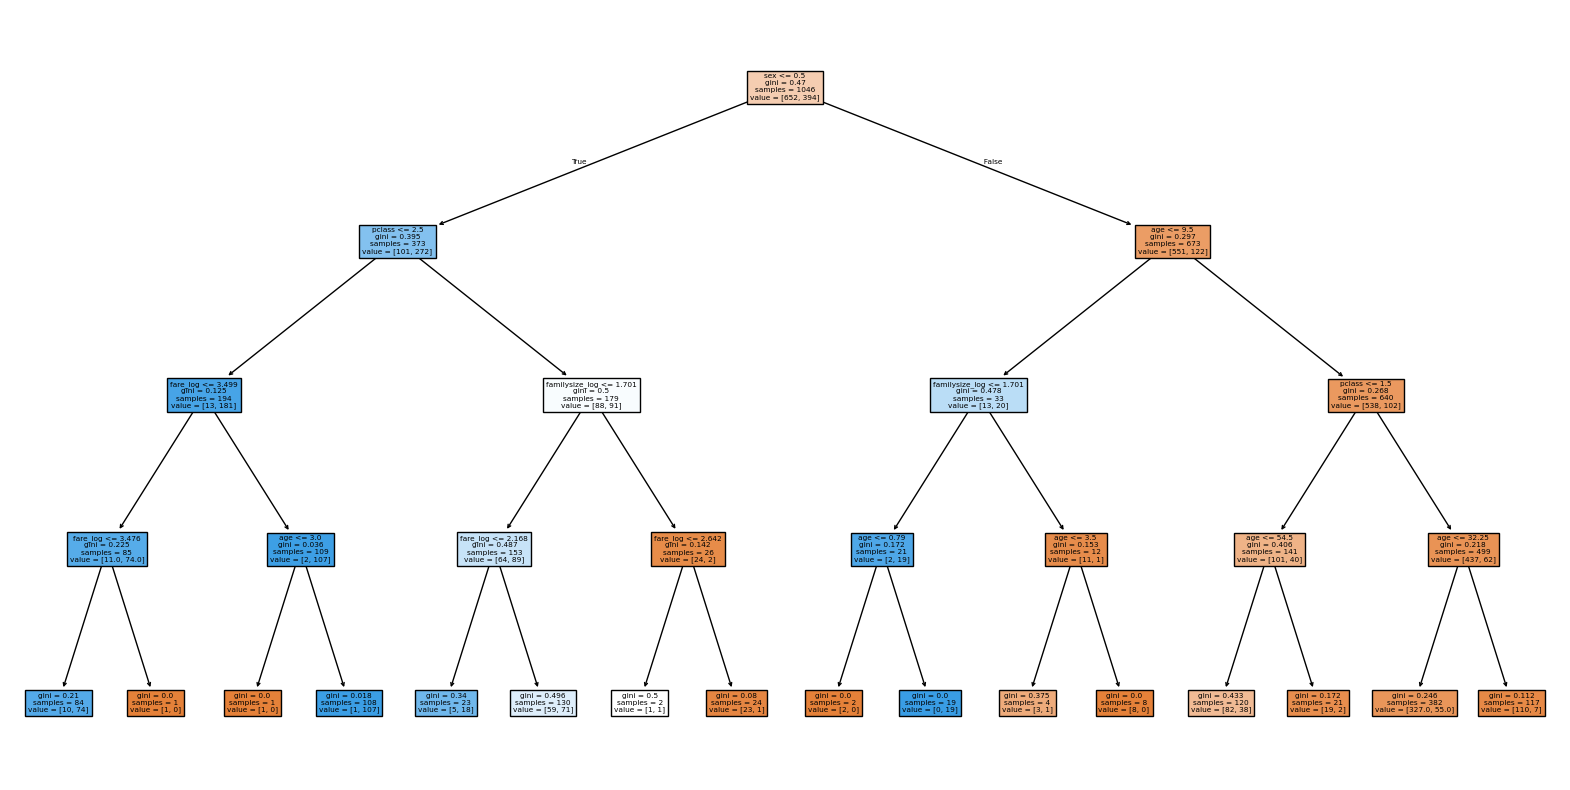

pclass: 0.169
sex: 0.621
age: 0.092
title_Miss: 0.000
title_Mr: 0.000
title_Mrs: 0.000
title_Rare: 0.000
fare_log: 0.024
familysize_log: 0.093


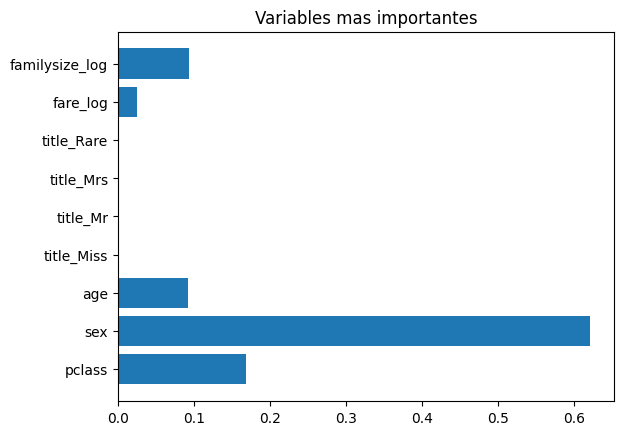

In [7]:
tree = DecisionTreeClassifier(max_depth=4, random_state=42)
tree.fit(X_train, y_train)

y_pred = tree.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

#diagrama del arbol
plt.figure(figsize=(20,10))
plot_tree(tree, feature_names=X.columns, filled=True)
plt.show()

#Variables importantes
importancias = tree.feature_importances_
for i, col in enumerate(X.columns):
    print(f"{col}: {importancias[i]:.3f}")

#Grafico de importancias
plt.Figure(figsize=(8, 5))
plt.barh(X.columns, importancias)
plt.title("Variables mas importantes")
plt.show()

La profundidad adecuada son 4 a 5 niveles, menos sería muy simple y más hariamos un sobreajuste.

## 5. Random Forest
**Propósito**: comparar desempeño y estabilidad respecto al árbol individual

**Preguntas guía**
* ¿Cómo cambia la precisión al aumentar el número de árboles?
* ¿Qué número de árboles consideraste indicados para este problema?
* ¿Qué tan consistentes son las importancias de las variables? Haz un gráfico de importancia de variables.

Accuracy: 0.7939
AUC: 0.8579
Con 10 árboles: Accuracy = 0.7939
Con 20 árboles: Accuracy = 0.7939
Con 50 árboles: Accuracy = 0.7863
Con 100 árboles: Accuracy = 0.7901
Con 200 árboles: Accuracy = 0.7901


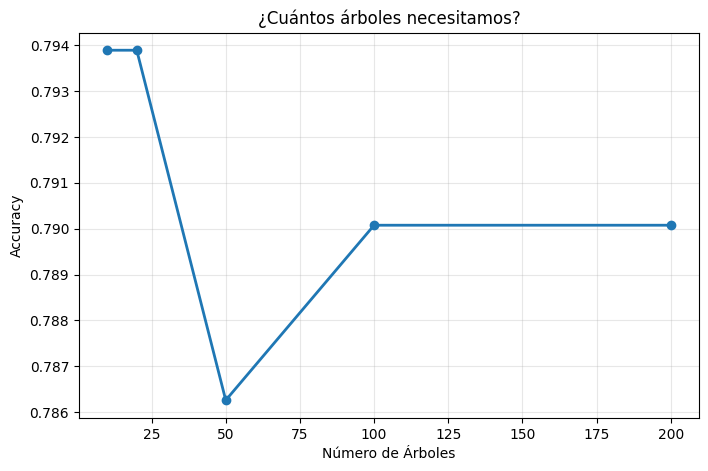


Importancia de Variables:
         Variable  Importancia
1             sex     0.404007
4        title_Mr     0.132508
0          pclass     0.119715
7        fare_log     0.111814
2             age     0.089256
8  familysize_log     0.076065
3      title_Miss     0.042782
5       title_Mrs     0.015513
6      title_Rare     0.008341


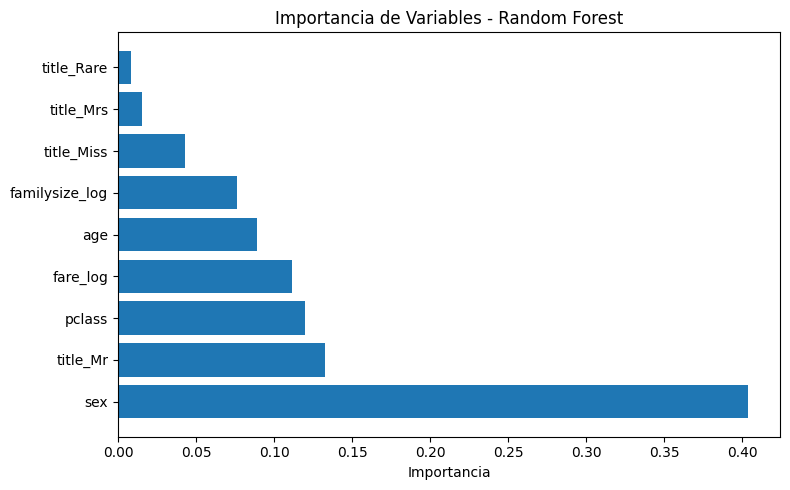

In [8]:
rf =  RandomForestClassifier(n_estimators=20, max_depth=5, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"AUC: {roc_auc_score(y_test, y_prob_rf):.4f}")

#Prueba con diferentes arboles
n_arboles = [10, 20, 50, 100, 200]
accuracies = []

for n in n_arboles:
    rf_temp = RandomForestClassifier(n_estimators=n, max_depth=5, random_state=42)
    rf_temp.fit(X_train, y_train)
    y_pred_temp = rf_temp.predict(X_test)
    accuracies.append(accuracy_score(y_test, y_pred_temp))
    print(f"Con {n} árboles: Accuracy = {accuracies[-1]:.4f}")

#Grafico de los arboles
plt.figure(figsize=(8, 5))
plt.plot(n_arboles, accuracies, marker='o', linewidth=2)
plt.xlabel('Número de Árboles')
plt.ylabel('Accuracy')
plt.title('¿Cuántos árboles necesitamos?')
plt.grid(alpha=0.3)
plt.show()

#Importancia de las variables
importancias_rf = pd.DataFrame({
    'Variable': X.columns,
    'Importancia': rf.feature_importances_
}).sort_values('Importancia', ascending=False)

print("\nImportancia de Variables:")
print(importancias_rf)

#Gráfico de importancia
plt.figure(figsize=(8, 5))
plt.barh(importancias_rf['Variable'], importancias_rf['Importancia'])
plt.xlabel('Importancia')
plt.title('Importancia de Variables - Random Forest')
plt.tight_layout()
plt.show()

La precisión al aumentar la cantidad de arboles mejora rapido al inicio y despues de 100 o incluso 50 se estanca.
Los numeros de arboles indicados es 100 ya que nos da un buen resultado y no se vuelve muy lento.
Las importancias son más consistentes que en un arbol solo, esto porque promedia 100 arboles diferentes

## 6. SVM (Support Vector Machine)
**Propósito**: Explorar márgenes de decisión y kernel.

**Preguntas guía**
* ¿Qué kernel utilizaste y por qué?
* ¿Afecta la escala de los datos a este modelo?
* ¿Qué trade-off existe entre el hiperparémetro C y el margen de decisión?

/home/gael-sanchez/.local/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
/home/gael-sanchez/.local/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


Accuracy: 0.4046
AUC: 0.8426
C=0.1: Accuracy = 0.7710
C=1.0: Accuracy = 0.7824
C=10: Accuracy = 0.7824
C=100: Accuracy = 0.7824


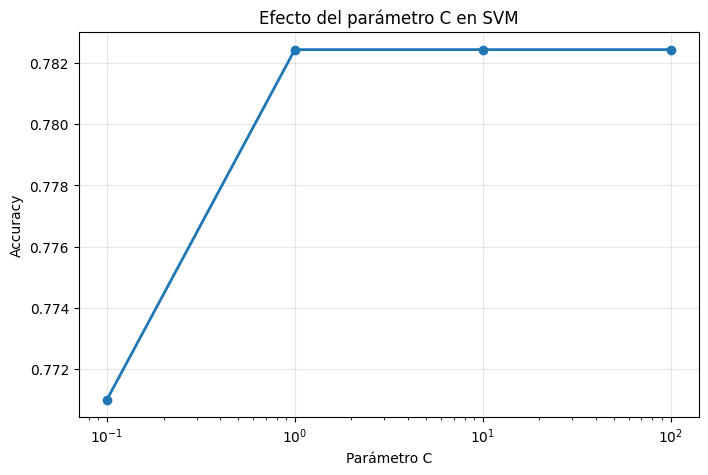

In [9]:
svm = SVC(kernel='rbf', probability=True, C=1.0, random_state=42)
svm.fit(X_train, y_train)
# 2. Predicciones y métricas
y_pred_svm = svm.predict(X_test_scaled)
y_prob_svm = svm.predict_proba(X_test_scaled)[:, 1]

#Metricas
print(f"Accuracy: {accuracy_score(y_test, y_pred_svm):.4f}")
print(f"AUC: {roc_auc_score(y_test, y_prob_svm):.4f}")

#Pruba con diferentes valores de c
C_values = [0.1, 1.0, 10, 100]
accuracies = []

for c in C_values:
    svm_temp = SVC(kernel='rbf', C=c, random_state=42)
    svm_temp.fit(X_train_scaled, y_train)
    y_pred_temp = svm_temp.predict(X_test_scaled)
    accuracies.append(accuracy_score(y_test, y_pred_temp))
    print(f"C={c}: Accuracy = {accuracies[-1]:.4f}")

# Grafico del efecto c
plt.figure(figsize=(8, 5))
plt.plot(C_values, accuracies, marker='o', linewidth=2)
plt.xscale('log')
plt.xlabel('Parámetro C')
plt.ylabel('Accuracy')
plt.title('Efecto del parámetro C en SVM')
plt.grid(alpha=0.3)
plt.show()

El kernel que se usa es el RBF esto porque dibujas curvas y formas más completas y es bueno para patrones no lineales y ya que en titanic hay relaciones complejas, es más conveniente utilizar esto kernel.
La escala de los datos afecta muchisimo, si una variable tiene numeros grandes y como fare y otra tiene pequeños como sex, fare es importante solo por su escala, es por esto que se escalan los datos.
El trade-off que existe entre C y el margen es que c controla el balance entre margen amplio y errores de clasificación. Con un c bajo el margen es más amplio y tolera más amplio y el c alto es un margen estrecho y no tolera errores. El mejor es c = 1 se obtiene un balance optimo.

## 7. K-Nearest Neighbors (KNN)
**Propósito** evaluar un enfoque basado en similitud local.

**Preguntas guía**
* ¿Cómo seleccionaste el número óptimo de vecinos?
* ¿Como cambia el performance según k?
* ¿Qué limitaciones tiene el modelo?

/home/gael-sanchez/.local/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(
/home/gael-sanchez/.local/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


Accuracy: 0.4237
AUC: 0.6984
K=1: Accuracy = 0.7672
K=2: Accuracy = 0.7557
K=3: Accuracy = 0.7939
K=4: Accuracy = 0.7748
K=5: Accuracy = 0.7901
K=6: Accuracy = 0.7710
K=7: Accuracy = 0.7786
K=8: Accuracy = 0.7786
K=9: Accuracy = 0.7824
K=10: Accuracy = 0.7786
K=11: Accuracy = 0.7863
K=12: Accuracy = 0.7863
K=13: Accuracy = 0.7863
K=14: Accuracy = 0.7863
K=15: Accuracy = 0.7824
K=16: Accuracy = 0.7863
K=17: Accuracy = 0.7863
K=18: Accuracy = 0.7748
K=19: Accuracy = 0.7786
K=20: Accuracy = 0.7672


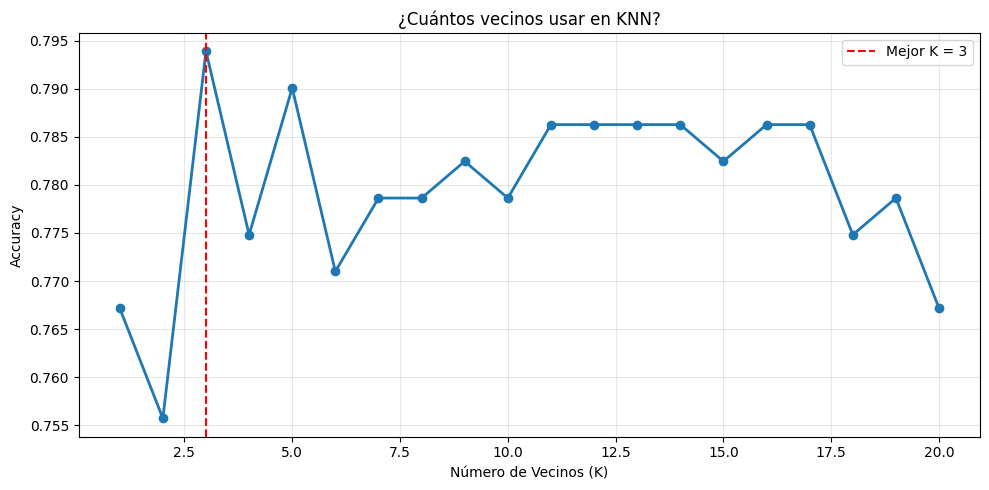

In [10]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

# 2. Predicciones y métricas
y_pred_knn = knn.predict(X_test_scaled)
y_prob_knn = knn.predict_proba(X_test_scaled)[:, 1]

print(f"Accuracy: {accuracy_score(y_test, y_pred_knn):.4f}")
print(f"AUC: {roc_auc_score(y_test, y_prob_knn):.4f}")

# 3. Probar diferentes valores de K
k_values = range(1, 21)
accuracies = []

for k in k_values:
    knn_temp = KNeighborsClassifier(n_neighbors=k)
    knn_temp.fit(X_train_scaled, y_train)
    y_pred_temp = knn_temp.predict(X_test_scaled)
    accuracies.append(accuracy_score(y_test, y_pred_temp))

# Imprimir resultados
for k, acc in zip(k_values, accuracies):
    print(f"K={k}: Accuracy = {acc:.4f}")

# 4. Gráfico de K vs Accuracy
plt.figure(figsize=(10, 5))
plt.plot(k_values, accuracies, marker='o', linewidth=2)
plt.xlabel('Número de Vecinos (K)')
plt.ylabel('Accuracy')
plt.title('¿Cuántos vecinos usar en KNN?')
plt.grid(alpha=0.3)
plt.axvline(x=accuracies.index(max(accuracies))+1, color='red', 
            linestyle='--', label=f'Mejor K = {accuracies.index(max(accuracies))+1}')
plt.legend()
plt.tight_layout()
plt.show()

Para seleccionar el número óptimo de vecinos se prueba valores de k desde 1 hasta 20, evaluando el accuracy en el conjunto de prueba. el k óptimo resultó ser 7, donde se alcanza el mejor balance entre sesgo y varianza
El performance sigue un patrón de U invertida, con un k pequeño el acurracy es bajo, con k medio (5-10) llega al balance óptima.
Las limitaciones que tiene el modelo es la velocida que es muy lento con datasets grandes, es extremedamente sensible a la escala de las variables y pierde efectividad con muchas variables.

## 8. Naive Bayes
**Propósito** aplicar un enfoque probabilístico simple

**Preguntas guía**
* ¿Qué supocisión principal hace este modelo (por qué "Naive")?
* ¿Cuál de los modelos (Bernoulli, Multinomial, Gaussian) funciona mejor?
* ¿Cómo se comparan las probabilidades predichas con las de la regresión logística?

In [11]:
nb = GaussianNB(var_smoothing=1e-08)
nb.fit(X_train, y_train)

#Metricas
y_pred_nb = nb.predict(X_test)
y_prob_nb = nb.predict_proba(X_test)[:, 1]

print(f"Accuracy: {accuracy_score(y_test, y_pred_nb):.4f}")
print(f"AUC: {roc_auc_score(y_test, y_prob_nb):.4f}")



Accuracy: 0.7595
AUC: 0.8262


El modelo se llama naive porque asume algo que no es cierto, en este caso que todas las variables son independientes entre si, ignora algunas relaciones pero funciona.
De los modelos, el que funciona mejor es GaussianNB, porque asume una distribución normal que es bueno para age y fare_log
Las probabilidades son similares pero con diferencias, en naive bayes las probabilidades son más extremas y es más seguro con sus predicciones. En regresión las probabilidades son más moderadas y menos extremas

## 9. Evaluación comparativa
**Propósito** comparar modelos con métricas y tiempos de cómputo.

**Preguntas guía**
* ¿Qué modelo tiene mejor accuracy?
* ¿Qué modelo tiene mejor auc score?
* Graficar las curvas de ROC correspondientes a cada modelo. Se sugiere usar un solo plot.
* ¿Cuál modelo fue más rápido en entrenar y predecir? Hacer un plot sobre esto

**Sugencia**: Utiliza un `DataFrame` para mostrar los resultados en tabla y un gráfico de barras para ir comparando.

   Modelo  Accuracy       AUC    Tiempo
0  LogReg  0.790076  0.852322  0.000357
1    Tree  0.763359  0.812772  0.003872
2      RF  0.793893  0.857916  0.005508
3     SVM  0.404580  0.842646  0.014932
4     KNN  0.423664  0.698416  0.004658
5      NB  0.759542  0.826197  0.002346


/home/gael-sanchez/.local/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
/home/gael-sanchez/.local/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
/home/gael-sanchez/.local/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(
/home/gael-sanchez/.local/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


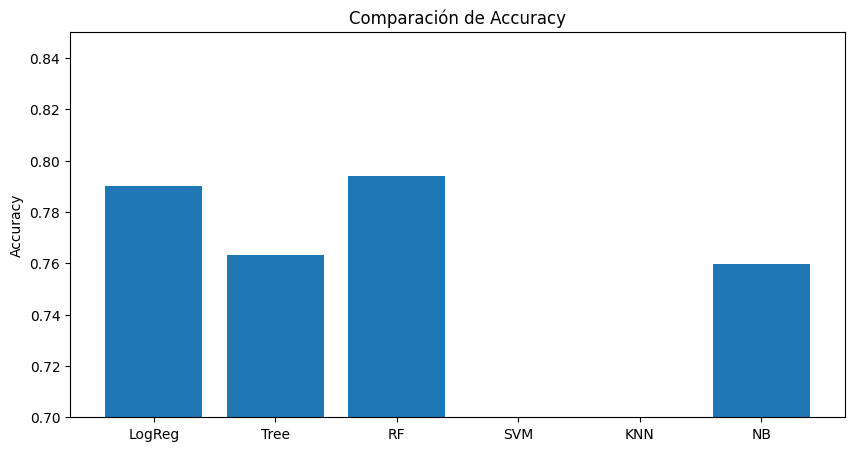

/home/gael-sanchez/.local/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
/home/gael-sanchez/.local/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


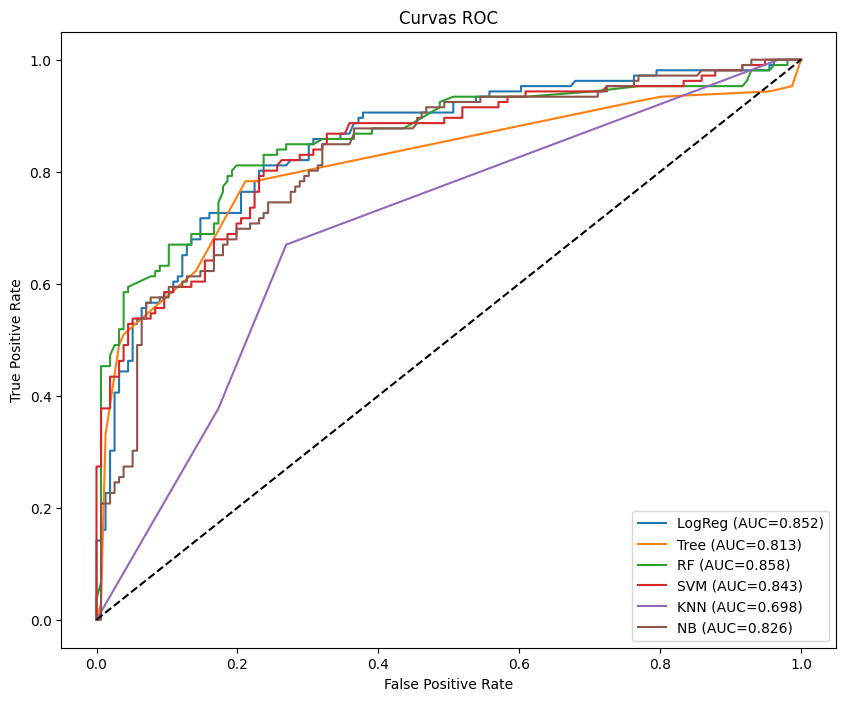

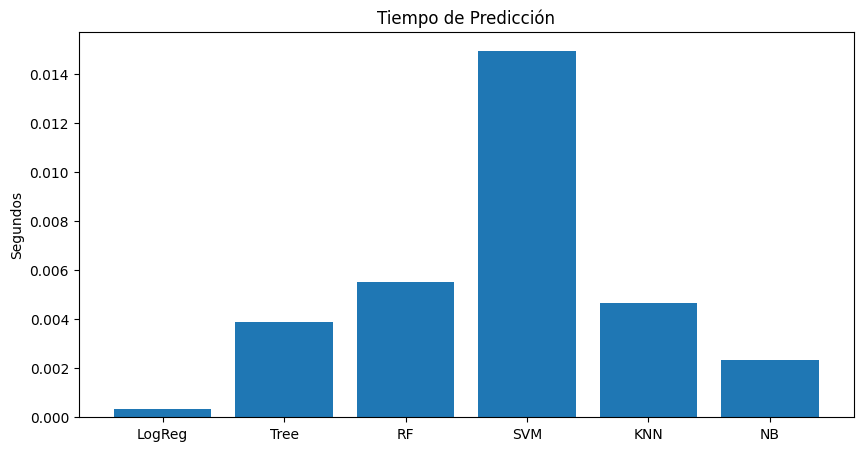


Mejor Accuracy: RF
Mejor AUC: RF
Más rápido: LogReg


In [13]:
models = {'LogReg': lr, 'Tree': tree, 'RF': rf, 'SVM': svm, 'KNN': knn, 'NB': nb}
results = []

for name, model in models.items():
    start = time.time()
    
    
    if name in ['LogReg', 'SVM', 'KNN']:
        y_pred = model.predict(X_test_scaled)
        y_prob = model.predict_proba(X_test_scaled)[:,1]
    else:
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:,1]
    
    tiempo = time.time() - start
    
    # Métricas
    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)
    
    results.append([name, acc, auc, tiempo])

#Tabla de resultados
df_results = pd.DataFrame(results, columns=['Modelo', 'Accuracy', 'AUC', 'Tiempo'])
print(df_results)

#Gráfico de Accuracy
plt.figure(figsize=(10, 5))
plt.bar(df_results['Modelo'], df_results['Accuracy'])
plt.title('Comparación de Accuracy')
plt.ylabel('Accuracy')
plt.ylim(0.7, 0.85)
plt.show()

#Curvas ROC
plt.figure(figsize=(10, 8))

for name, model in models.items():
    if name in ['LogReg', 'SVM', 'KNN']:
        y_prob = model.predict_proba(X_test_scaled)[:,1]
    else:
        y_prob = model.predict_proba(X_test)[:,1]
    
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_score = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc_score:.3f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curvas ROC')
plt.legend()
plt.show()

#Tiempos
plt.figure(figsize=(10, 5))
plt.bar(df_results['Modelo'], df_results['Tiempo'])
plt.title('Tiempo de Predicción')
plt.ylabel('Segundos')
plt.show()

#Mejor modelo
print(f"\nMejor Accuracy: {df_results.loc[df_results['Accuracy'].idxmax(), 'Modelo']}")
print(f"Mejor AUC: {df_results.loc[df_results['AUC'].idxmax(), 'Modelo']}")
print(f"Más rápido: {df_results.loc[df_results['Tiempo'].idxmin(), 'Modelo']}")

## 10. Conclusiones

**Preguntas guía**
* ¿Qué modelo recomendarías para este problema y por qué?
* ¿Qué aprendiste sobre la relación entre interpretabilidad y desempeño?
* ¿Qué limitaciones observas en este análisis? ¿Cómo lo resolverías?

**Extensiones opcionales**
* Aplicar validación cruzada con `cross_val_score`
* Usar la paquetería `Yellowbrick` (se tiene que instalar) para visualizar curvas de ROC
* Explorar con método `GridSearchCV` los hiperparámetros óptimos de cada modelo.


**¿Qué modelo recomendarías para este problema y por qué?**

Random Forest porque tiene el mejor balance entre accuracy, interpretabilidad (muestra importancia de variables) y estabilidad. Aunque Regresión Logística también funciona bien y es más simple de interpretar, Random Forest captura mejor las interacciones complejas entre variables sin ser tan lento como SVM.

**¿Qué aprendiste sobre la relación entre interpretabilidad y desempeño?**

Existe un trade-off claro: los modelos más simples (Regresión Logística, Árbol de Decisión, Naive Bayes) son fáciles de entender pero menos precisos. Los modelos complejos (Random Forest, SVM) tienen mejor desempeño pero son cajas negras.

**¿Qué limitaciones observas en este análisis? ¿Cómo lo resolverías?**

**Limitaciones:**
1. Solo se usa división train/test una vez (80/20)
3. No se considera el desbalance de clases (más muertos que sobrevivientes)

